# Telco Customer Churn EDA

## Objective
Explore the Telco customer churn dataset to identify the main patterns and factors associated with churn.

## Data Overview
The dataset contains 7,043 customer-level records from a telecommunications company, released by IBM as a realistic example for churn modeling. Each row represents one customer and includes service usage, contract details, billing information, and a binary churn label. It contains both categorical and numerical variables.

In [103]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load and Inspect Data

In [104]:
df = pd.read_csv("C:\\Users\\ishan\\OneDrive - Dalhousie University\\SUMMER 2026\\telco-churn-retention-ml\\data\\raw\\telco_churn.csv")
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [105]:
df.shape
df.columns
df.dtypes
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Churn Distribution
Before exploring the feature relationships, we first check the distribution of the target variable to see whether the dataset is imbalanced.

In [106]:
df["Churn"].value_counts() #moderate class imbalance 
df["Churn"].value_counts(normalize=True) * 100   #b converts class count into percentages

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [107]:
print("Target column: Churn")
print("Meaning: Yes = customer left, No = customer stayed")

Target column: Churn
Meaning: Yes = customer left, No = customer stayed


### 1. Churn Distribution
This chart shows the class balance of the target variable, `Churn`. It helps us see whether the dataset is imbalanced.



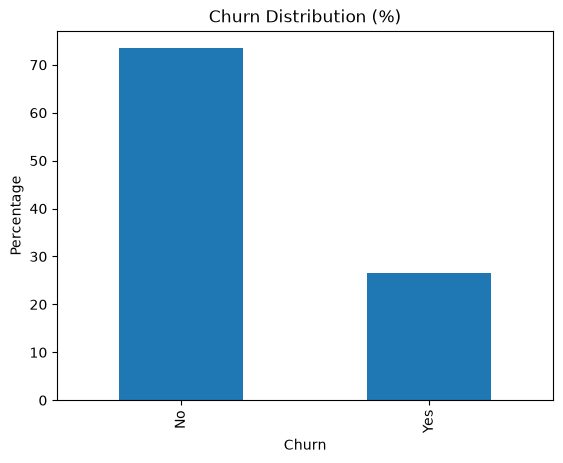

In [108]:
pct = df["Churn"].value_counts(normalize=True).sort_index() * 100
ax = pct.plot(kind="bar")
ax.set_ylabel("Percentage")
ax.set_xlabel("Churn")
ax.set_title("Churn Distribution (%)")
plt.savefig('../figures/churn_distribution.png')
plt.show()

The churn target is moderately imbalanced, with the majority of customers in the `No` class and a smaller but still significant portion in the `Yes` class.

### 2. Churn by Contract Type
This chart shows how churn varies across the three contract types: month-to-month, one year, and two year. It helps us see which contract type is associated with higher churn.

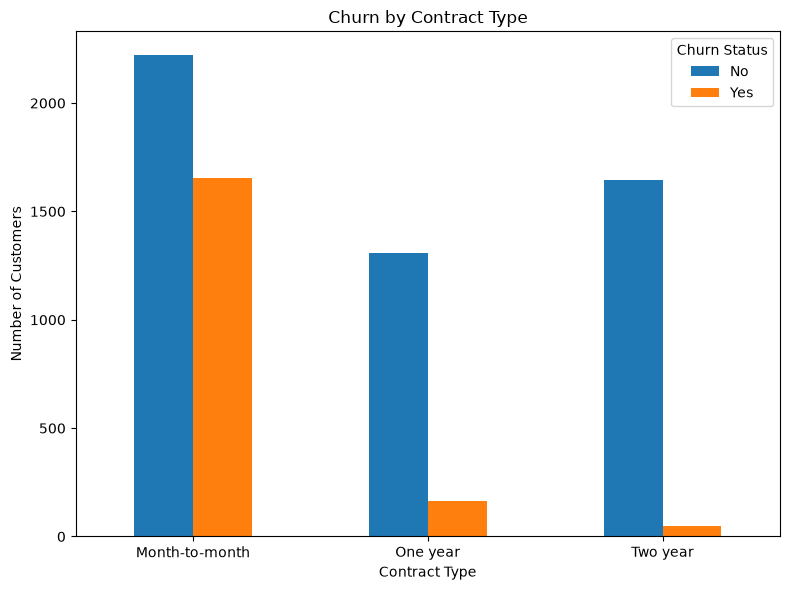

In [109]:
ct = pd.crosstab(df["Contract"], df["Churn"])
ct.plot(kind="bar",  figsize=(8, 6), title="Churn by Contract Type")

# Add labels
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/churn_by_contract_type.png')
plt.show()

The chart shows that month-to-month customers are associated with the highest churn, indicating that short-term contracts are a major churn risk factor.

### 3. Churn by Tenure
This chart shows how churn is distributed across different tenure values. It helps us see whether customers with shorter tenure are more likely to churn.

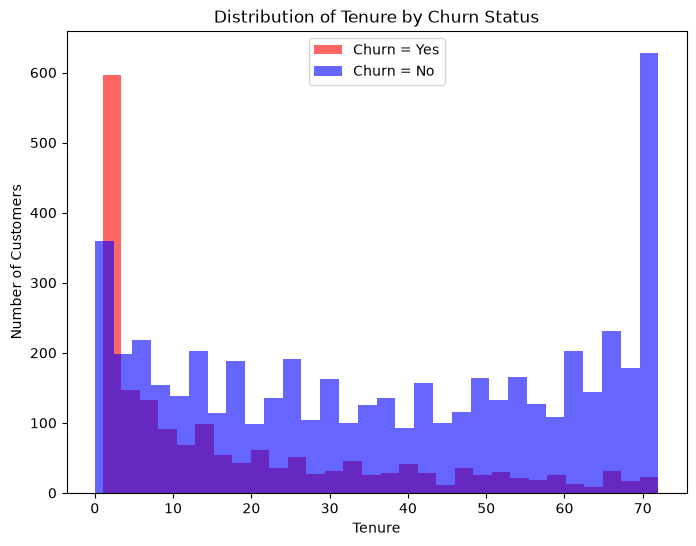

In [110]:
plt.figure(figsize=(8, 6))

plt.hist(df[df["Churn"] == "Yes"]["tenure"], bins=30, alpha=0.6, label="Churn = Yes", color="red")
plt.hist(df[df["Churn"] == "No"]["tenure"], bins=30, alpha=0.6, label="Churn = No", color="blue")

plt.title("Distribution of Tenure by Churn Status")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.legend()
plt.savefig('../figures/churn_by_tenure.png')
plt.show()

The chart indicates that churn is highest among customers with low tenure and generally declines as tenure increases, suggesting that early-stage customers are more vulnerable to churn.

### 4. Churn by Monthly Charges
This chart shows the relationship between monthly charges and churn. It helps us identify whether customers with higher monthly charges are more likely to leave.

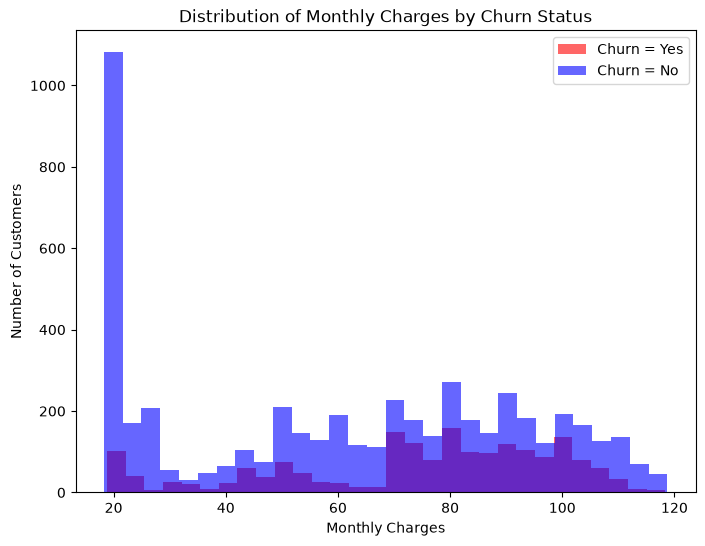

In [111]:
plt.figure(figsize=(8, 6))

plt.hist(df[df["Churn"] == "Yes"]["MonthlyCharges"], bins=30, alpha=0.6, label="Churn = Yes", color="red")
plt.hist(df[df["Churn"] == "No"]["MonthlyCharges"], bins=30, alpha=0.6, label="Churn = No", color="blue")

plt.title("Distribution of Monthly Charges by Churn Status")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.legend()
plt.savefig('../figures/churn_by_monthly_charges.png')
plt.show()

This suggests that higher monthly charges may be associated with a greater risk of churn.

### 5. Churn by Payment Method
This chart shows how churn varies across the four payment methods: bank transfer, credit card, electronic check, and mailed check.

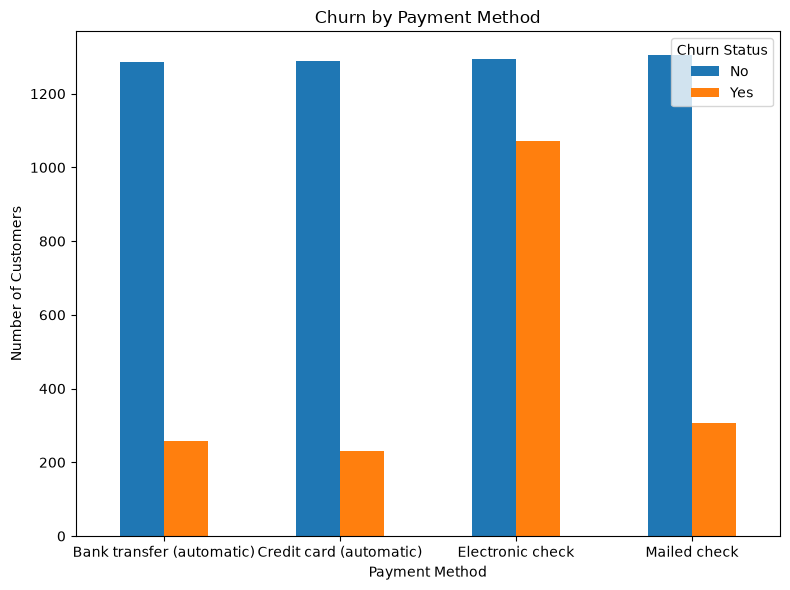

In [112]:
df["PaymentMethod"].unique()
ct = pd.crosstab(df["PaymentMethod"], df["Churn"])
ct.plot(kind="bar",  figsize=(8, 6), title="Churn by Payment Method")

# Add labels
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.legend(title="Churn Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/churn_by_payment_method.png')
plt.show()

This suggests that customers using electronic check are more likely to churn than customers using the other payment methods.

### 6. Churn by Service Subscriptions
The following charts show each service and how churn varies across different service subscription categories.

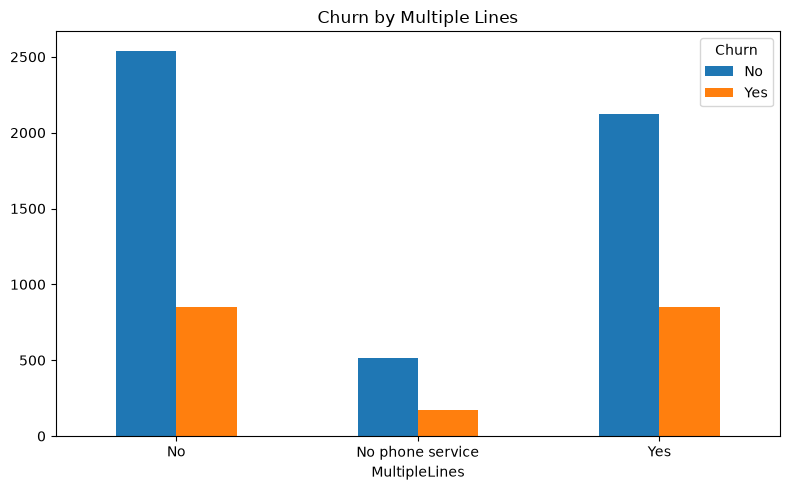

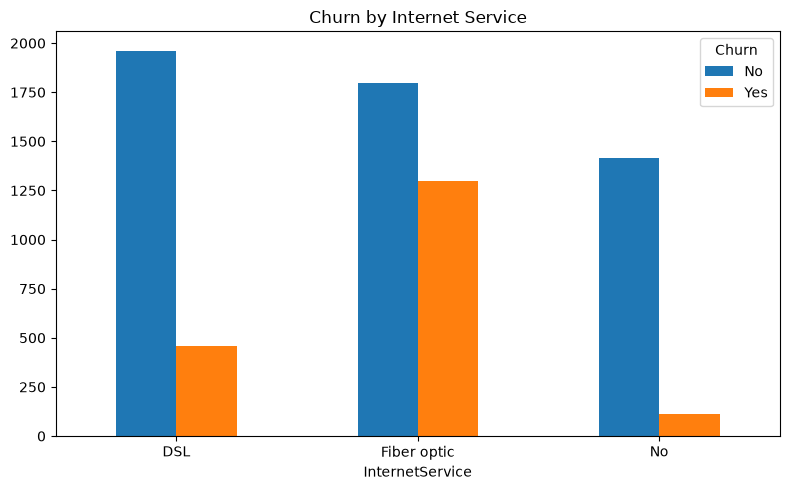

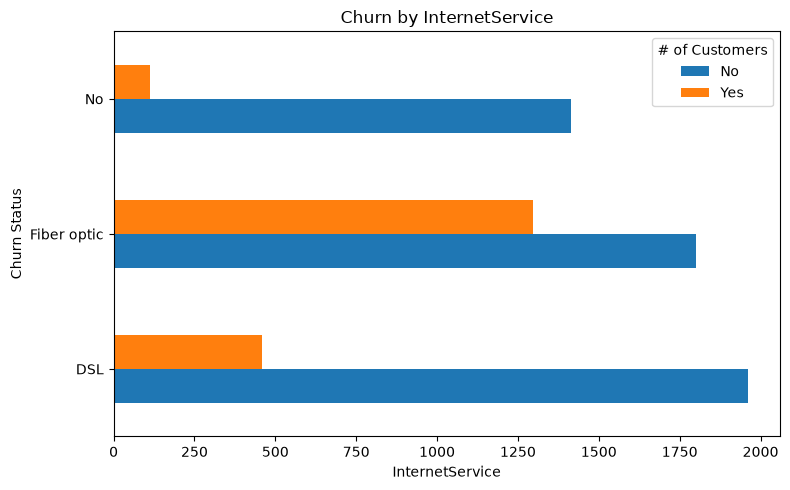

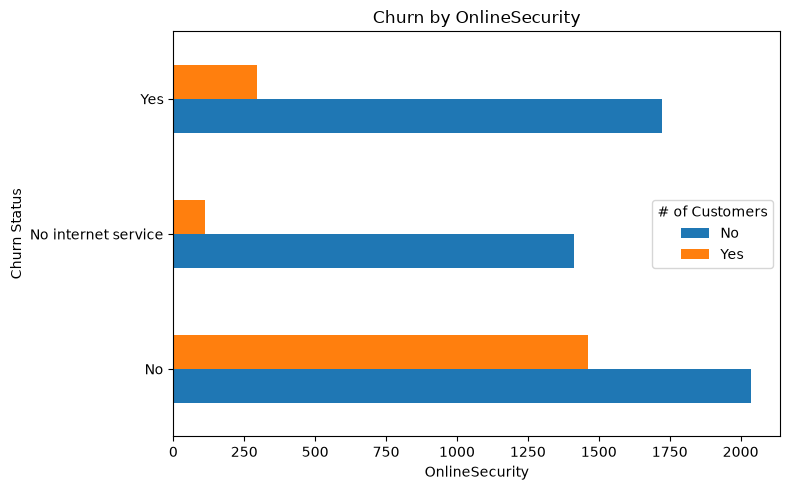

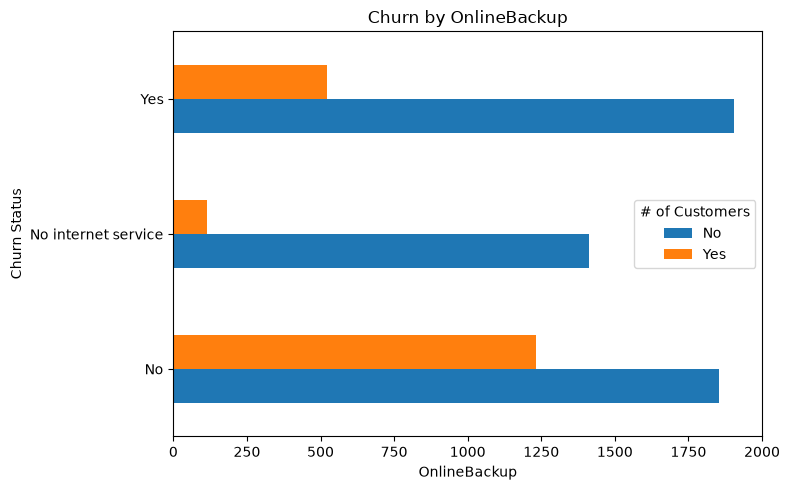

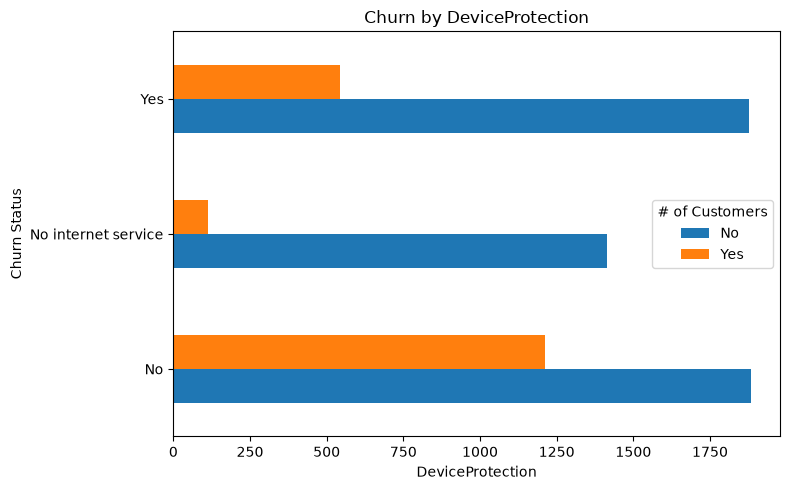

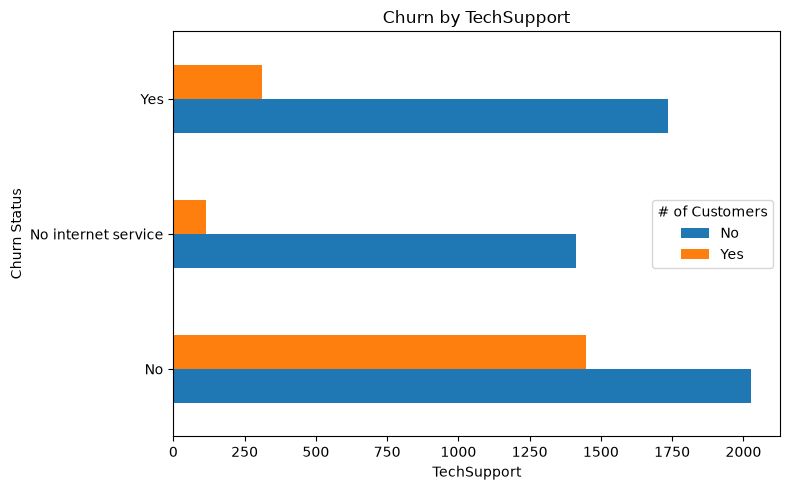

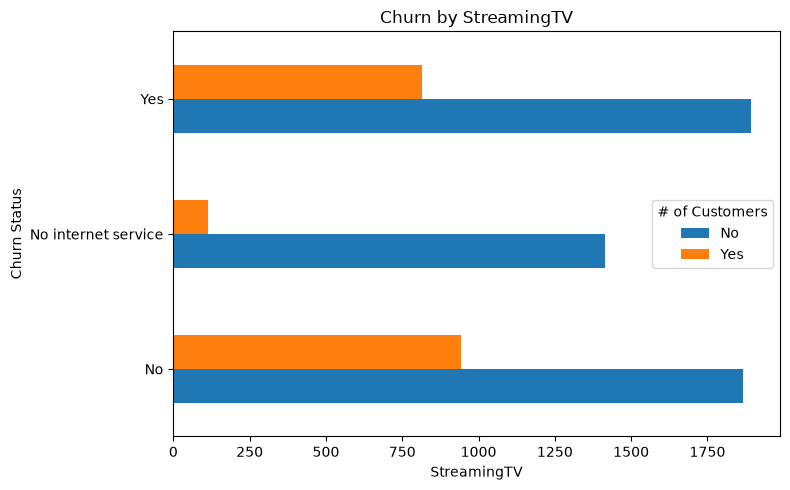

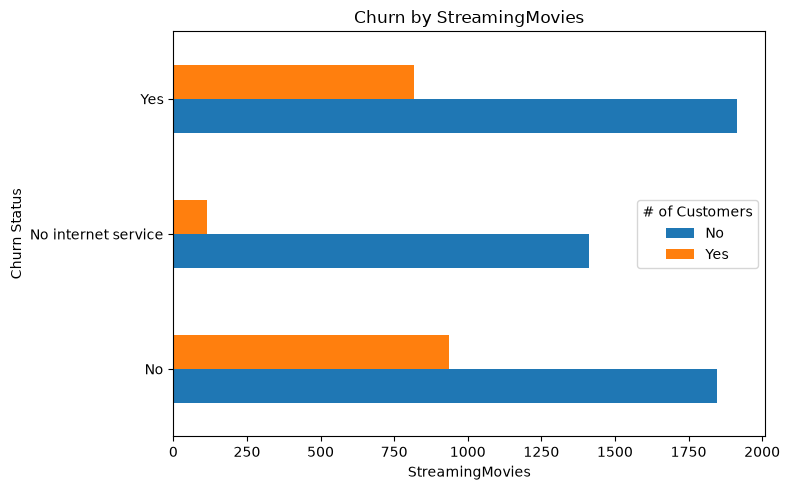

In [113]:
ct1 = pd.crosstab(df["MultipleLines"], df["Churn"])
ct1.plot(kind="bar", figsize=(8, 5), title="Churn by Multiple Lines")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/churn_by_multiple_lines_service.png')
plt.show()

ct2 = pd.crosstab(df["InternetService"], df["Churn"])
ct2.plot(kind="bar", figsize=(8, 5), title="Churn by Internet Service")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/churn_by_internet_service.png')
plt.show()


service_cols = [
    "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies"
]

for col in service_cols:
    ct = pd.crosstab(df[col], df["Churn"])
    ct.plot(kind="barh", figsize=(8, 5), title=f"Churn by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Status")
    plt.legend(title="# of Customers")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'../figures/churn_by_{col.lower()}.png')
    plt.show()


## Conclusion
The exploratory data analysis shows clear patterns in customer churn. Month-to-month contracts, shorter tenure, higher monthly charges, and electronic check payments are all associated with higher churn. The target variable is moderately imbalanced, so future modeling should account for class imbalance when evaluating performance. Overall, the analysis provides useful direction for building a churn prediction model and identifying retention opportunities.